In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [4]:
churn_data=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [5]:
churn_data["TotalCharges"] = pd.to_numeric(churn_data["TotalCharges"], errors='coerce')
churn_data["MonthlyCharges"] = pd.to_numeric(churn_data["MonthlyCharges"], errors='coerce')

In [6]:
churn_data["SeniorCitizen"] = churn_data["SeniorCitizen"].map({1: "Yes", 0: "No"})

In [7]:
churn_data["Churn"] = churn_data["Churn"].map({"No": 0, "Yes": 1})


In [8]:
print("\nMissing values:")
print(churn_data.isnull().sum())


Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [9]:
churn_data = churn_data.dropna(subset=["TotalCharges"])

In [10]:
print(churn_data.isnull().sum())
print(churn_data.shape)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
(7032, 21)


In [11]:
X = churn_data.drop(columns=["Churn"])
y = churn_data["Churn"]

# Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric columns:", numeric_features)
print("Categorical columns:", categorical_features)


Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, random_state=42, class_weight="balanced"
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400, random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

results = []
fitted_models = {}


In [15]:
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

    y_pred = pipeline.predict(X_test)

    # probabilities if available
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc
    })

results_churn = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print("\nModel Comparison:")
print(results_churn)



Model Comparison:
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
3    Gradient Boosting  0.795309   0.644295  0.513369  0.571429  0.838829
1        Random Forest  0.787491   0.622150  0.510695  0.560940  0.821061
2          Extra Trees  0.776830   0.594340  0.505348  0.546243  0.809683
4                  KNN  0.762615   0.551282  0.574866  0.562827  0.795794
0  Logistic Regression  0.744847   0.513612  0.756684  0.611892  0.835023


In [16]:
best_model_name = results_churn.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print(f"\nBest model based on Accuracy: {best_model_name}")
print(f"Best Accuracy: {results_churn.iloc[0]['Accuracy']:.4f}")



Best model based on Accuracy: Gradient Boosting
Best Accuracy: 0.7953


In [17]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 most important factors affecting churn:")
print(importance_df.head(10))

most_important_factor = importance_df.iloc[0]["Feature"]
print(f"\nMost important factor affecting churn: {most_important_factor}")



Top 10 most important factors affecting churn:
             Feature  Importance
5             tenure    0.029898
15          Contract    0.028761
8    InternetService    0.018716
18    MonthlyCharges    0.009192
17     PaymentMethod    0.008339
12       TechSupport    0.005259
2      SeniorCitizen    0.004643
16  PaperlessBilling    0.004122
9     OnlineSecurity    0.002180
4         Dependents    0.001848

Most important factor affecting churn: tenure


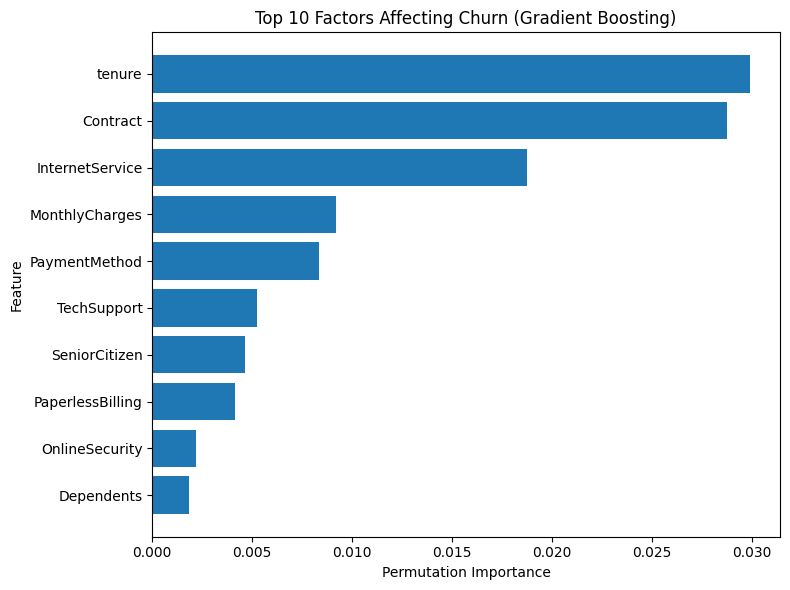

In [18]:
top_n = 10
top_features = importance_df.head(top_n).sort_values(by="Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title(f"Top {top_n} Factors Affecting Churn ({best_model_name})")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [19]:
# Best model 
final_model = fitted_models["Gradient Boosting"]

# Predict leave/stay for each row in the test set
y_pred = final_model.predict(X_test)

# Predict probability of churn (class 1 = leave)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Build a results table
results = X_test.copy()
results["Actual_Churn"] = y_test.values
results["Predicted_Churn"] = y_pred
results["Churn_Probability"] = y_prob

# Map labels to readable text
results["Predicted_Label"] = results["Predicted_Churn"].map({0: "Stay", 1: "Leave"})
results["Actual_Label"] = results["Actual_Churn"].map({0: "Stay", 1: "Leave"})

# Show the first few predictions
print(results[["Actual_Label", "Predicted_Label", "Churn_Probability"]].head(10))

     Actual_Label Predicted_Label  Churn_Probability
974          Stay            Stay           0.037014
619          Stay           Leave           0.655056
4289         Stay            Stay           0.026644
3721        Leave            Stay           0.154738
4533         Stay            Stay           0.090773
445         Leave            Stay           0.446384
5898         Stay            Stay           0.041197
3387         Stay            Stay           0.107666
1346        Leave           Leave           0.637069
5690         Stay            Stay           0.033311


In [20]:
# customers most likely to leave
high_risk_customers = results.sort_values("Churn_Probability", ascending=False)
print(high_risk_customers[["Actual_Label", "Predicted_Label", "Churn_Probability"]].head(20))

     Actual_Label Predicted_Label  Churn_Probability
3380        Leave           Leave           0.879123
4585        Leave           Leave           0.871328
2464        Leave           Leave           0.855388
582         Leave           Leave           0.849122
6240        Leave           Leave           0.848134
2753        Leave           Leave           0.838871
3727        Leave           Leave           0.836050
383         Leave           Leave           0.835692
6633        Leave           Leave           0.833292
2631        Leave           Leave           0.831927
3159         Stay           Leave           0.828928
2797        Leave           Leave           0.825567
2367        Leave           Leave           0.822928
642         Leave           Leave           0.821759
2397        Leave           Leave           0.821546
1731        Leave           Leave           0.820732
2607        Leave           Leave           0.820732
2275        Leave           Leave           0.

In [21]:
results.to_csv("churn_predictions.csv", index=False)

print("Prediction file saved successfully as churn_predictions.csv")

Prediction file saved successfully as churn_predictions.csv
